In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [12]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [13]:
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [14]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')
print(grouped_df)

          Дата  Количество продаж
0   2018-01-04               1840
1   2018-01-05               1301
2   2018-01-06               1306
3   2018-01-07               1322
4   2018-01-09               1719
..         ...                ...
200 2018-08-26               1462
201 2018-08-28               1731
202 2018-08-29               1497
203 2018-08-30               1445
204 2018-08-31               1366

[205 rows x 2 columns]


Вывести несколько первых строк сгруппированных данных

In [15]:
print(grouped_df.head())

        Дата  Количество продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


Нарисуйте график продаж у `grouped_df`

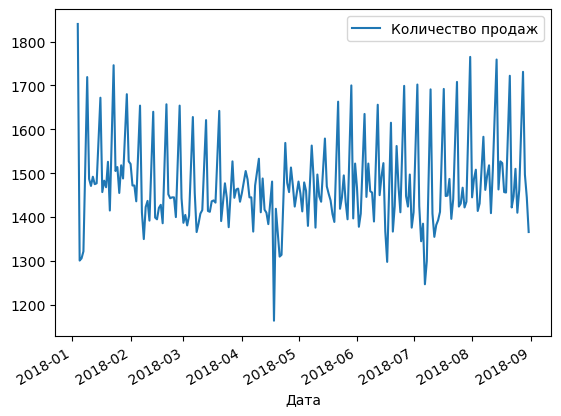

In [16]:
import matplotlib.pyplot as plt

grouped_df.plot(x='Дата', y='Количество продаж')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [17]:
print("Продажи в целом стабильные (около 1400–1500), без явного роста или падения. Есть частые резкие скачки вверх (до ~1800) и редкие провалы вниз (до ~1200). Колебания регулярные, особенно заметны пики.")

Продажи в целом стабильные (около 1400–1500), без явного роста или падения. Есть частые резкие скачки вверх (до ~1800) и редкие провалы вниз (до ~1200). Колебания регулярные, особенно заметны пики.


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [18]:
outlier_row = grouped_df.loc[grouped_df['Количество продаж'].idxmax()]
print(outlier_row)

Дата                 2018-01-04 00:00:00
Количество продаж                   1840
Name: 0, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [19]:
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')

filtered = df[
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Дата'].dt.weekday == 2)
]

grouped = filtered.groupby(['Склад', 'Номенклатура'])['Количество'].sum().reset_index()

top_products = grouped.loc[grouped.groupby('Склад')['Количество'].idxmax()]

print(top_products)

    Склад Номенклатура  Количество
1       1    product_1        2981
24      2    product_1        2887
46      3    product_1        2267
69      4    product_1        2385
92      5    product_1        1956


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

Index(['Дата', 'T'], dtype='object')


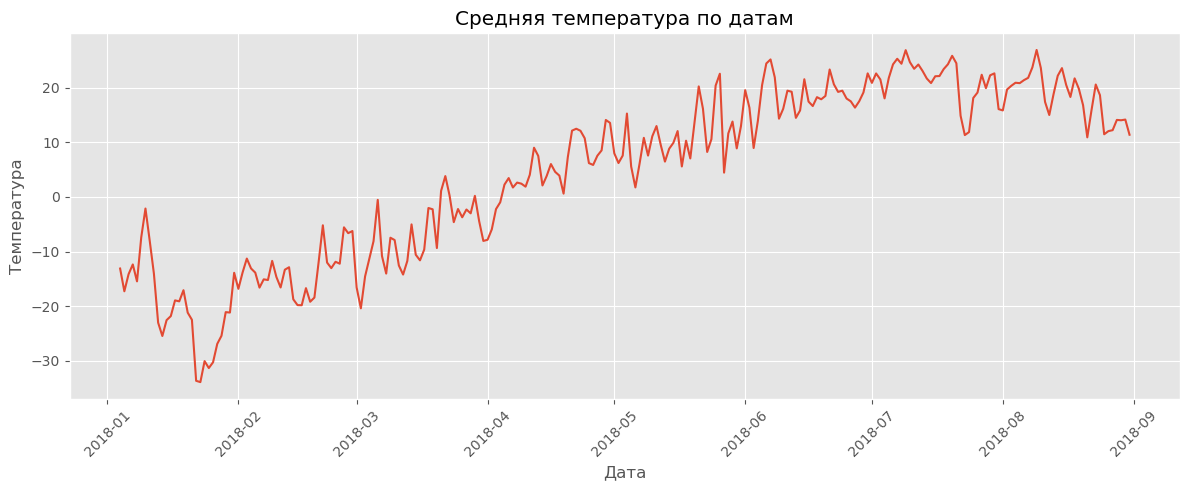

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка CSV файла
df = pd.read_csv('converted_weather.csv')

# Проверка названий колонок
print(df.columns)

# Преобразуем столбец с датой
df['Дата'] = pd.to_datetime(df['Дата'])

# Группировка по датам и расчет средней температуры
daily_temp = df.groupby('Дата')['T'].mean().reset_index()

# Построение графика
plt.figure(figsize=(12, 5))

plt.plot(
    daily_temp['Дата'],
    daily_temp['T']
)

# Подписи
plt.title('Средняя температура по датам')
plt.xlabel('Дата')
plt.ylabel('Температура')

# Поворот дат
plt.xticks(rotation=45)

# Сетка
plt.grid(True)

# Красивое отображение
plt.tight_layout()

# Показ графика
plt.show()

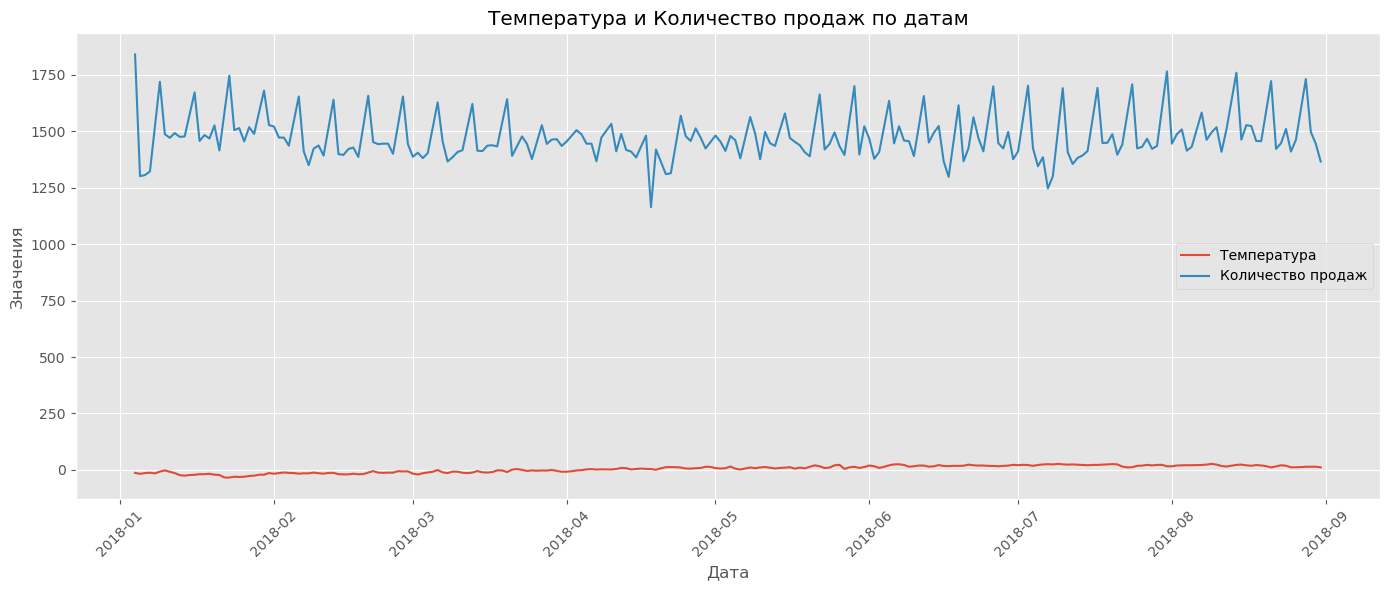

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка weather файла
df = pd.read_csv('converted_weather.csv')

# Преобразуем дату
df['Дата'] = pd.to_datetime(df['Дата'])
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата'])

# Средняя температура по дням
daily_temp = df.groupby('Дата')['T'].mean().reset_index()

# Создаем график
plt.figure(figsize=(14, 6))

# Линия температуры
plt.plot(
    daily_temp['Дата'],
    daily_temp['T'],
    label='Температура'
)

# Линия продаж
plt.plot(
    grouped_df['Дата'],
    grouped_df['Количество продаж'],
    label='Количество продаж'
)

# Заголовок и подписи
plt.title('Температура и Количество продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Значения')

# Легенда
plt.legend()

# Сетка
plt.grid(True)

# Поворот дат
plt.xticks(rotation=45)

# Красивое отображение
plt.tight_layout()

# Показ графика
plt.show()